In [ ]:
pip install numpy opencv-python matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def show_images(images, titles, cmap='gray', figsize=(14, 6)):
  n = len(images)
  plt.figure(figsize=figsize)
  for i in range(n):
    plt.subplot(1, n, i + 1)

    if len(images[i].shape) == 2:
      plt.imshow(images[i], cmap=cmap)
    else:
      plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')
    plt.tight_layout()

plt.show()

(1200, 1200) uint8


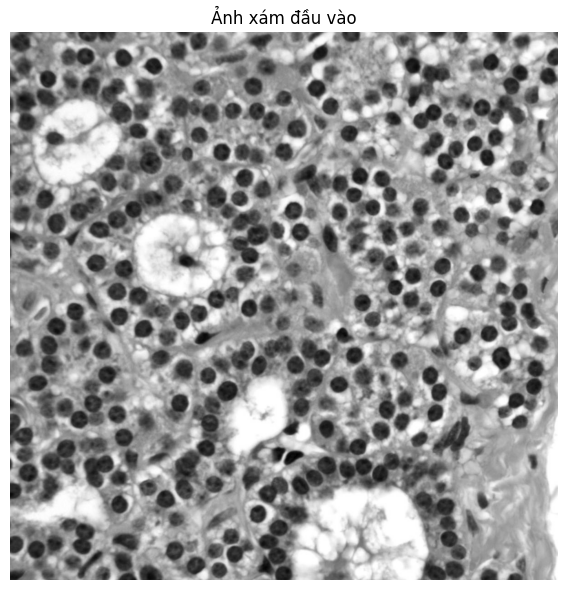

In [ ]:
img = cv2.imread("/content/drive/MyDrive/Classroom/MAT3562E Computer Vision (Eng) 2025-2026 HK2 Computer Vision - MAT3562E/data/cell2.jpg", cv2.IMREAD_GRAYSCALE)

print(img.shape, img.dtype)

show_images([img], ["Ảnh xám đầu vào"])

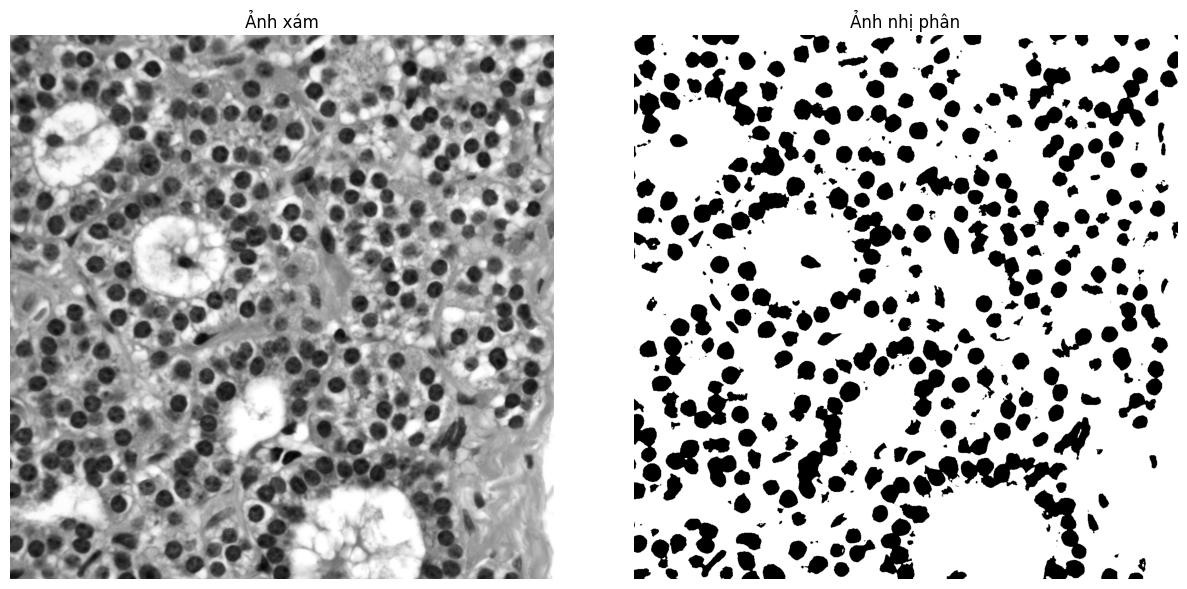

In [ ]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
show_images([img, binary], ["Ảnh xám", "Ảnh nhị phân"])

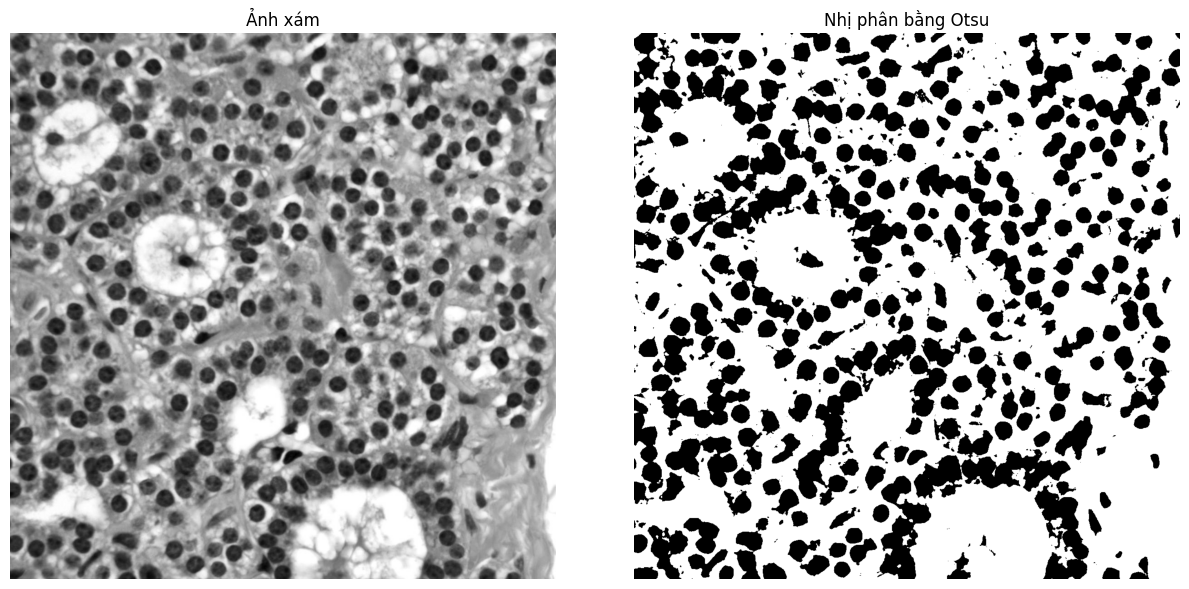

In [ ]:
_, binary_otsu = cv2.threshold(
img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
show_images([img, binary_otsu], ["Ảnh xám", "Nhị phân bằng Otsu"])

In [ ]:
kernel_3 = np.ones((3, 3), np.uint8)
kernel_5 = np.ones((5, 5), np.uint8)
ellipse_5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cross_5 = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
print(kernel_3)
print(ellipse_5)
print(cross_5)

[[1 1 1]
 [1 1 1]
 [1 1 1]]
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]


In [ ]:
def grayscale_erosion_numpy(img, ksize=3):
  pad = ksize // 2
  padded = np.pad(img, pad, mode='edge')
  out = np.zeros_like(img)
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      region = padded[i:i+ksize, j:j+ksize]
      out[i, j] = np.min(region)
  return out

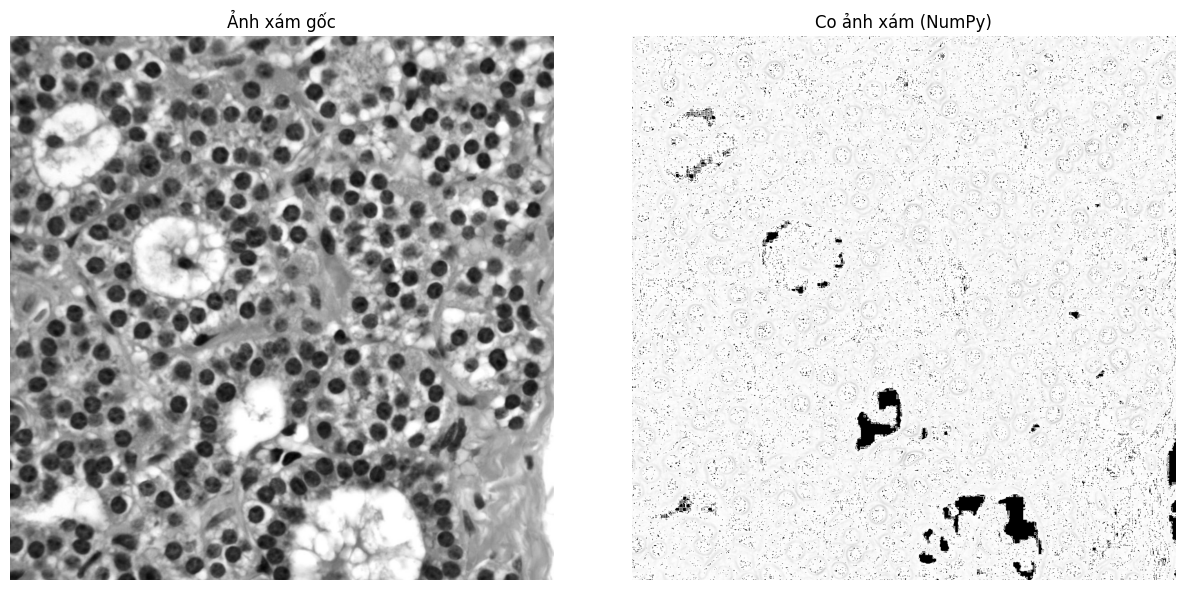

In [ ]:
eroded_gray_np = grayscale_erosion_numpy(img, ksize=3)
show_images([img, eroded_gray_np], ["Ảnh xám gốc", "Co ảnh xám (NumPy)"])

new = np.abs(eroded_gray_np - img)
plt.imshow(new, cmap='gray')
